In [1]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

from transformers import AutoModel

model = AutoModel.from_pretrained(checkpoint)

from pathlib import Path
import dill

with open(f"{Path.home()}/tutorial_5_best_model.pkl", "rb") as f:
    base_model = dill.load(f)


    
from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
2026-02-08 21:14:21.531276948 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"
INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


# Lab 3: Mixed Precision Quantization Search

## Task 1 — Per-layer Integer Width Search

> *"In Tutorial 6, all layers allocated to IntegerLinear are allocated the same width and fractional width. This is suboptimal, as different layers may have different sensitivities to quantization. Modify the code to allow different layers to have widths in the range [8, 16, 32] and fractional widths in the range [2, 4, 8]. Expose this choice as an additional hyperparameter for the Optuna sampler. Run the search again, and plot a figure that has the number of trials on the x axis, and the maximum achieved accuracy up to that point on the y axis."*

In [2]:
# Task 1: Per-layer Integer width search
# Search space: each Linear layer independently chooses nn.Linear or LinearInteger
# with per-layer width ∈ {8, 16, 32} and frac_width ∈ {2, 4, 8}

import torch
from chop.nn.quantized.modules.linear import LinearInteger
from chop.tools.utils import deepsetattr
from copy import deepcopy

task1_search_space = {
    "int_width": [8, 16, 32],
    "frac_width": [2, 4, 8],
    "linear_layer_choices": [torch.nn.Linear, LinearInteger],
}


def construct_model_task1(trial):
    trial_model = deepcopy(base_model)

    for name, layer in trial_model.named_modules():
        if isinstance(layer, torch.nn.Linear):
            new_layer_cls = trial.suggest_categorical(
                f"{name}_type",
                task1_search_space["linear_layer_choices"],
            )

            if new_layer_cls == torch.nn.Linear:
                continue

            # Per-layer width and frac_width selection
            idx_w = trial.suggest_int(
                f"{name}_width_idx", 0, len(task1_search_space["int_width"]) - 1
            )
            idx_f = trial.suggest_int(
                f"{name}_frac_width_idx", 0, len(task1_search_space["frac_width"]) - 1
            )
            w = task1_search_space["int_width"][idx_w]
            f = task1_search_space["frac_width"][idx_f]

            kwargs = {
                "in_features": layer.in_features,
                "out_features": layer.out_features,
                "config": {
                    "data_in_width": w,
                    "data_in_frac_width": f,
                    "weight_width": w,
                    "weight_frac_width": f,
                    "bias_width": w,
                    "bias_frac_width": f,
                },
            }

            new_layer = LinearInteger(**kwargs)
            new_layer.weight.data = layer.weight.data.clone()
            if layer.bias is not None:
                new_layer.bias.data = layer.bias.data.clone()
            deepsetattr(trial_model, name, new_layer)

    return trial_model

In [3]:
# Task 1: Run the search
from chop.tools import get_trainer
from optuna.samplers import RandomSampler
import optuna

def objective_task1(trial):
    model = construct_model_task1(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=2,
    )

    trainer.train()
    eval_results = trainer.evaluate()
    trial.set_user_attr("model", model)
    return eval_results["eval_accuracy"]

study_task1 = optuna.create_study(
    direction="maximize",
    study_name="task1-per-layer-integer-search",
    sampler=RandomSampler(),
)

study_task1.optimize(
    objective_task1,
    n_trials=20,
    timeout=60 * 60 * 24,
)

[I 2026-02-08 21:14:25,925] A new study created in memory with name: task1-per-layer-integer-search
/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'torch.nn.modules.linear.Linear'> which is of type type.
  warnings.warn(message)
/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'chop.nn.quantized.modules.linear.LinearInteger'> which is of type type.
  warnings.warn(message)
/home/ism/ADL/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.645500
1000,0.424400
1500,0.389300
2000,0.359100
2500,0.351800
3000,0.360900
3500,0.306400
4000,0.290800
4500,0.276400
5000,0.305200


[I 2026-02-08 21:16:39,434] Trial 0 finished with value: 0.87716 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.query_width_idx': 2, 'bert.encoder.layer.0.attention.self.query_frac_width_idx': 0, 'bert.encoder.layer.0.attention.self.value_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.value_width_idx': 1, 'bert.encoder.layer.0.attention.self.value_frac_width_idx': 0, 'bert.encoder.layer.0.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.output.dense_width_idx': 1, 'bert.encoder.layer.0.output.dense_frac_width_idx': 2, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.attention.output.dense_width_idx'

Step,Training Loss
500,0.374200
1000,0.352200
1500,0.348400
2000,0.345800
2500,0.318900
3000,0.371200
3500,0.296900
4000,0.280200
4500,0.267900
5000,0.291900


[I 2026-02-08 21:18:30,418] Trial 1 finished with value: 0.87976 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.query_width_idx': 0, 'bert.encoder.layer.0.attention.self.query_frac_width_idx': 1, 'bert.encoder.layer.0.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.attention.output.dense_width_idx': 0, 'bert.encoder.layer.1.attention.output.dense_frac_width_idx': 1, 'bert.encoder.layer.1.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'classifier_ty

...

[I 2026-02-08 21:48:48,880] Trial 17 finished with value: 0.87872 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.query_width_idx': 0, 'bert.encoder.layer.0.attention.self.query_frac_width_idx': 1, 'bert.encoder.layer.0.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.intermediate.dense_width_idx': 1, 'bert.encoder.layer.0.intermediate.dense_frac_width_idx': 2, 'bert.encoder.layer.0.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.attention.output.dense_width_idx': 2, 'bert.encoder.layer.1.attention.output.dense_frac_width_idx': 1, 'bert.encoder.layer.1.intermediate.dense_type': <class

Step,Training Loss
500,0.648500
1000,0.434800
1500,0.391500
2000,0.357300
2500,0.349800
3000,0.344400
3500,0.304100
4000,0.277100
4500,0.254900
5000,0.280200


[I 2026-02-08 21:50:33,384] Trial 18 finished with value: 0.87332 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.self.value_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.value_width_idx': 1, 'bert.encoder.layer.0.attention.self.value_frac_width_idx': 0, 'bert.encoder.layer.0.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.intermediate.dense_width_idx': 1, 'bert.encoder.layer.1.intermediate.dense_frac_width_idx': 0, 'bert.encoder.layer.1.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'classifier_type': <c

Step,Training Loss
500,0.466500
1000,0.371800
1500,0.357000
2000,0.350500
2500,0.337800
3000,0.370900
3500,0.307300
4000,0.271700
4500,0.267700
5000,0.279000


[I 2026-02-08 21:52:13,176] Trial 19 finished with value: 0.87368 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.query_width_idx': 2, 'bert.encoder.layer.0.attention.self.query_frac_width_idx': 0, 'bert.encoder.layer.0.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.intermediate.dense_width_idx': 1, 'bert.encoder.layer.0.intermediate.dense_frac_width_idx': 0, 'bert.encoder.layer.0.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'classifier_type': <c

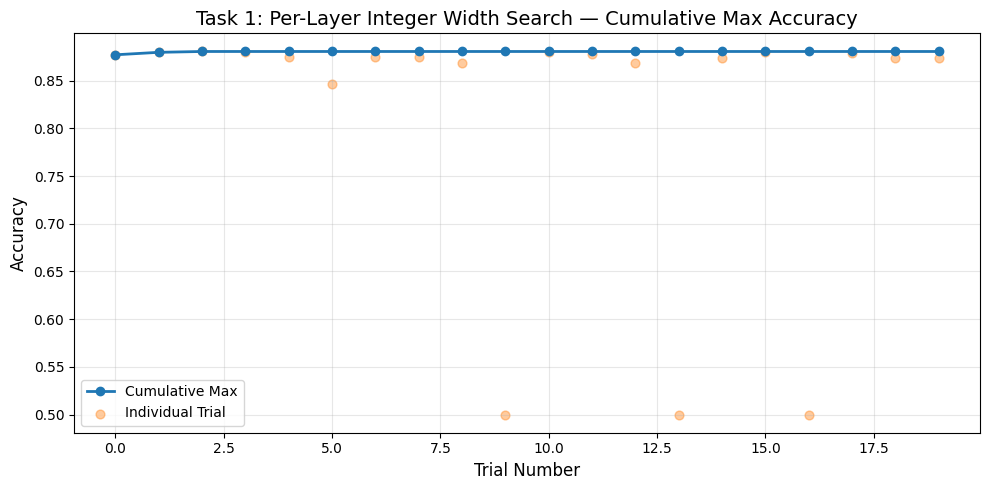


Best Trial #2: accuracy = 0.8806
Per-layer configurations:
  bert.encoder.layer.0.attention.self.query: LinearInteger(width=8, frac_width=4)
  bert.encoder.layer.0.attention.self.value: nn.Linear (full precision)
  bert.encoder.layer.0.intermediate.dense: LinearInteger(width=16, frac_width=2)
  bert.encoder.layer.0.output.dense: nn.Linear (full precision)
  bert.encoder.layer.1.attention.output.dense: LinearInteger(width=16, frac_width=8)
  bert.encoder.layer.1.intermediate.dense: LinearInteger(width=32, frac_width=4)
  bert.encoder.layer.1.output.dense: LinearInteger(width=8, frac_width=4)
  classifier: nn.Linear (full precision)

Total trials: 20
Successful: 20


In [4]:
# Task 1: Plot cumulative maximum accuracy vs trial number
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract results
task1_results = []
for trial in study_task1.trials:
    # Determine per-layer config summary
    widths_used = set()
    fracs_used = set()
    is_quantized = False
    for key, val in trial.params.items():
        if key.endswith("_type") and val != torch.nn.Linear:
            is_quantized = True
        if key.endswith("_width_idx"):
            widths_used.add(task1_search_space["int_width"][val])
        if key.endswith("_frac_width_idx"):
            fracs_used.add(task1_search_space["frac_width"][val])

    task1_results.append({
        "trial_number": trial.number,
        "accuracy": trial.value if trial.value is not None else 0.0,
        "state": trial.state.name,
        "quantized": is_quantized,
        "widths": sorted(widths_used) if widths_used else [],
        "frac_widths": sorted(fracs_used) if fracs_used else [],
    })

df_task1 = pd.DataFrame(task1_results)

# Plot cumulative max accuracy
df_complete = df_task1[df_task1["state"] == "COMPLETE"].sort_values("trial_number")
cummax = df_complete["accuracy"].cummax()

plt.figure(figsize=(10, 5))
plt.plot(df_complete["trial_number"], cummax, marker='o', linewidth=2, color='tab:blue', label='Cumulative Max')
plt.scatter(df_complete["trial_number"], df_complete["accuracy"], alpha=0.4, color='tab:orange', s=40, label='Individual Trial')
plt.xlabel('Trial Number', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Task 1: Per-Layer Integer Width Search — Cumulative Max Accuracy', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print best trial details
best = study_task1.best_trial
print(f"\nBest Trial #{best.number}: accuracy = {best.value:.4f}")
print("Per-layer configurations:")
for key, val in sorted(best.params.items()):
    if key.endswith("_type"):
        layer_name = key.replace("_type", "")
        is_int = val != torch.nn.Linear
        if is_int:
            w_idx = best.params.get(f"{layer_name}_width_idx", "?")
            f_idx = best.params.get(f"{layer_name}_frac_width_idx", "?")
            w = task1_search_space["int_width"][w_idx] if isinstance(w_idx, int) else "?"
            f = task1_search_space["frac_width"][f_idx] if isinstance(f_idx, int) else "?"
            print(f"  {layer_name}: LinearInteger(width={w}, frac_width={f})")
        else:
            print(f"  {layer_name}: nn.Linear (full precision)")

print(f"\nTotal trials: {len(df_task1)}")
print(f"Successful: {len(df_complete)}")

## Task 2 — All Precision Types Search

> *"Extend the search to consider all supported precisions for the Linear layer in Mase, including Minifloat, BlockFP, BlockLog, Binary, etc. This may also require changing the model constructor so the required arguments are passed when instantiating each layer. Run the search again, and plot a figure that has the number of trials on the x axis, and the maximum achieved accuracy up to that point on the y axis. Plot one curve for each precision to compare their performance."*

All 10 quantized precision types are included after patching MASE library bugs:
- **LinearInteger**: Fixed-point quantization with configurable integer and fractional widths
- **LinearMinifloatDenorm/IEEE**: Low-precision floating-point with denormal or IEEE rounding
- **LinearLog**: Logarithmic quantization 
- **LinearBlockFP/BlockMinifloat/BlockLog**: Block-based quantization (required `block_size` as list and `backward()` signature fix)
- **LinearBinary/BinaryScaling**: Binary quantization (required dimension-agnostic fix in `BinaryBipolarScaled`/`BinaryZeroScaled`)
- **LinearBinaryResidualSign**: Binary with residual sign for multi-level quantization

In [5]:
# Defining Search Space

import torch
from chop.nn.quantized.modules.linear import (
    LinearInteger,
    LinearMinifloatDenorm,
    LinearMinifloatIEEE,
    LinearLog,
    LinearBlockFP,
    LinearBlockMinifloat,
    LinearBlockLog,
    LinearBinary,
    LinearBinaryScaling,
    LinearBinaryResidualSign,
)

search_space = {
    "frac_width": [2, 4, 8],
    "int_width": [8, 16, 32],
    "exponent_width": [2, 3, 4, 5],
    "block_size": [16, 32, 64],
    "linear_layer_choices": [
        torch.nn.Linear,
        LinearInteger,
        LinearMinifloatDenorm,
        LinearMinifloatIEEE,
        LinearLog,
        LinearBlockFP,
        LinearBlockMinifloat,
        LinearBlockLog,
        LinearBinary,
        LinearBinaryScaling,
        LinearBinaryResidualSign,
    ],
}


from chop.tools.utils import deepsetattr
from copy import deepcopy


def construct_model(trial):
    # Fetch the model
    trial_model = deepcopy(base_model)

    # Quantize layers according to optuna suggestions
    for name, layer in trial_model.named_modules():
        if isinstance(layer, torch.nn.Linear):
            new_layer_cls = trial.suggest_categorical(
                f"{name}_type",
                search_space["linear_layer_choices"],
            )

            if new_layer_cls == torch.nn.Linear:
                continue

            kwargs = {
                "in_features": layer.in_features,
                "out_features": layer.out_features,
            }

            # --- Integer ---
            if new_layer_cls == LinearInteger:
                idx_w = trial.suggest_int(f"{name}_int_width_idx", 0, len(search_space["int_width"]) - 1)
                idx_f = trial.suggest_int(f"{name}_frac_width_idx", 0, len(search_space["frac_width"]) - 1)
                
                kwargs["config"] = {
                    "data_in_width": search_space["int_width"][idx_w],
                    "data_in_frac_width": search_space["frac_width"][idx_f],
                    "weight_width": search_space["int_width"][idx_w],
                    "weight_frac_width": search_space["frac_width"][idx_f],
                    "bias_width": search_space["int_width"][idx_w],
                    "bias_frac_width": search_space["frac_width"][idx_f],
                }

            # --- Minifloat Denorm ---
            elif new_layer_cls == LinearMinifloatDenorm:
                idx_w = trial.suggest_int(f"{name}_mf_width_idx", 0, len(search_space["int_width"]) - 1)
                idx_e = trial.suggest_int(f"{name}_mf_exp_idx", 0, len(search_space["exponent_width"]) - 1)
                ew = search_space["exponent_width"][idx_e]
                
                kwargs["config"] = {
                    "weight_width": search_space["int_width"][idx_w],
                    "weight_exponent_width": ew,
                    "weight_exponent_bias": (2**(ew-1))-1,
                    "data_in_width": search_space["int_width"][idx_w],
                    "data_in_exponent_width": ew,
                    "data_in_exponent_bias": (2**(ew-1))-1,
                    "bias_width": search_space["int_width"][idx_w],
                    "bias_exponent_width": ew,
                    "bias_exponent_bias": (2**(ew-1))-1,
                }

            # --- Minifloat IEEE ---
            elif new_layer_cls == LinearMinifloatIEEE:
                idx_w = trial.suggest_int(f"{name}_ieee_width_idx", 0, len(search_space["int_width"]) - 1)
                idx_e = trial.suggest_int(f"{name}_ieee_exp_idx", 0, len(search_space["exponent_width"]) - 1)
                ew = search_space["exponent_width"][idx_e]

                kwargs["config"] = {
                    "weight_width": search_space["int_width"][idx_w],
                    "weight_exponent_width": ew,
                    "weight_exponent_bias": (2**(ew-1))-1,
                    "data_in_width": search_space["int_width"][idx_w],
                    "data_in_exponent_width": ew,
                    "data_in_exponent_bias": (2**(ew-1))-1,
                    "bias_width": search_space["int_width"][idx_w],
                    "bias_exponent_width": ew,
                    "bias_exponent_bias": (2**(ew-1))-1,
                }

            # --- Log ---
            elif new_layer_cls == LinearLog:
                idx_w = trial.suggest_int(f"{name}_log_width_idx", 0, len(search_space["int_width"]) - 1)
                kwargs["config"] = {
                    "weight_width": search_space["int_width"][idx_w],
                    "weight_exponent_bias": 127,
                    "data_in_width": search_space["int_width"][idx_w],
                    "data_in_exponent_bias": 127,
                    "bias_width": search_space["int_width"][idx_w],
                    "bias_exponent_bias": 127,
                }

            # --- Block FP ---
            elif new_layer_cls == LinearBlockFP:
                idx_w = trial.suggest_int(f"{name}_bfp_width_idx", 0, len(search_space["int_width"]) - 1)
                idx_b = trial.suggest_int(f"{name}_bfp_block_idx", 0, len(search_space["block_size"]) - 1)
                bs = [search_space["block_size"][idx_b]]

                kwargs["config"] = {
                    "weight_width": search_space["int_width"][idx_w],
                    "weight_exponent_width": 8,
                    "weight_exponent_bias": 127,
                    "weight_block_size": bs,
                    "data_in_width": search_space["int_width"][idx_w],
                    "data_in_exponent_width": 8,
                    "data_in_exponent_bias": 127,
                    "data_in_block_size": bs,
                    "bias_width": search_space["int_width"][idx_w],
                    "bias_exponent_width": 8,
                    "bias_exponent_bias": 127,
                    "bias_block_size": bs,
                }

            # --- Block Minifloat ---
            elif new_layer_cls == LinearBlockMinifloat:
                idx_w = trial.suggest_int(f"{name}_bmf_width_idx", 0, len(search_space["int_width"]) - 1)
                idx_e = trial.suggest_int(f"{name}_bmf_exp_idx", 0, len(search_space["exponent_width"]) - 1)
                idx_b = trial.suggest_int(f"{name}_bmf_block_idx", 0, len(search_space["block_size"]) - 1)
                bs = [search_space["block_size"][idx_b]]

                kwargs["config"] = {
                    "weight_width": search_space["int_width"][idx_w],
                    "weight_exponent_width": search_space["exponent_width"][idx_e],
                    "weight_exponent_bias_width": search_space["exponent_width"][idx_e],
                    "weight_block_size": bs,
                    "data_in_width": search_space["int_width"][idx_w],
                    "data_in_exponent_width": search_space["exponent_width"][idx_e],
                    "data_in_exponent_bias_width": search_space["exponent_width"][idx_e],
                    "data_in_block_size": bs,
                    "bias_width": search_space["int_width"][idx_w],
                    "bias_exponent_width": search_space["exponent_width"][idx_e],
                    "bias_exponent_bias_width": search_space["exponent_width"][idx_e],
                    "bias_block_size": bs,
                }

            # --- Block Log ---
            elif new_layer_cls == LinearBlockLog:
                idx_w = trial.suggest_int(f"{name}_blog_width_idx", 0, len(search_space["int_width"]) - 1)
                idx_b = trial.suggest_int(f"{name}_blog_block_idx", 0, len(search_space["block_size"]) - 1)
                bs = [search_space["block_size"][idx_b]]

                kwargs["config"] = {
                    "weight_width": search_space["int_width"][idx_w],
                    "weight_exponent_bias_width": 3,
                    "weight_block_size": bs,
                    "data_in_width": search_space["int_width"][idx_w],
                    "data_in_exponent_bias_width": 3,
                    "data_in_block_size": bs,
                    "bias_width": search_space["int_width"][idx_w],
                    "bias_exponent_bias_width": 3,
                    "bias_block_size": bs,
                }

            # --- Binary ---
            elif new_layer_cls == LinearBinary:
                kwargs["config"] = {
                    "weight_stochastic": trial.suggest_categorical(f"{name}_bin_stoch", [True, False]),
                    "weight_bipolar": trial.suggest_categorical(f"{name}_bin_bipol", [True, False]),
                }

            # --- Binary Scaling ---
            elif new_layer_cls == LinearBinaryScaling:
                kwargs["config"] = {
                    "data_in_stochastic": trial.suggest_categorical(f"{name}_bins_in_stoch", [True, False]),
                    "bias_stochastic": False,
                    "weight_stochastic": trial.suggest_categorical(f"{name}_bins_w_stoch", [True, False]),
                    "data_in_bipolar": True,
                    "bias_bipolar": True,
                    "weight_bipolar": True,
                    "binary_training": True,
                }

            # --- Binary Residual Sign ---
            elif new_layer_cls == LinearBinaryResidualSign:
                kwargs["config"] = {
                    "data_in_stochastic": trial.suggest_categorical(f"{name}_brs_in_stoch", [True, False]),
                    "weight_stochastic": trial.suggest_categorical(f"{name}_brs_w_stoch", [True, False]),
                    "data_in_bipolar": True,
                    "weight_bipolar": True,
                    "binary_training": True,
                    "data_in_levels": 2,
                    "data_in_residual_sign": True,
                }

            # Create the new layer (copy the weights)
            new_layer = new_layer_cls(**kwargs)
            new_layer.weight.data = layer.weight.data.clone()
            if layer.bias is not None and hasattr(new_layer, 'bias') and new_layer.bias is not None:
                new_layer.bias.data = layer.bias.data.clone()

            # Replace the layer in the model
            deepsetattr(trial_model, name, new_layer)

    return trial_model


### Task 2: Smoke Test & Study Execution

In [6]:
# Quick smoke test: forward + backward pass for every layer type with 2D Linear weights
import torch
from chop.nn.quantized.modules.linear import (
    LinearInteger,
    LinearMinifloatDenorm,
    LinearMinifloatIEEE,
    LinearLog,
    LinearBlockFP,
    LinearBlockMinifloat,
    LinearBlockLog,
    LinearBinary,
    LinearBinaryScaling,
    LinearBinaryResidualSign,
)

test_configs = {
    "LinearInteger": (LinearInteger, {
        "data_in_width": 8, "data_in_frac_width": 4,
        "weight_width": 8, "weight_frac_width": 4,
        "bias_width": 8, "bias_frac_width": 4,
    }),
    "LinearMinifloatDenorm": (LinearMinifloatDenorm, {
        "weight_width": 8, "weight_exponent_width": 3, "weight_exponent_bias": 3,
        "data_in_width": 8, "data_in_exponent_width": 3, "data_in_exponent_bias": 3,
        "bias_width": 8, "bias_exponent_width": 3, "bias_exponent_bias": 3,
    }),
    "LinearMinifloatIEEE": (LinearMinifloatIEEE, {
        "weight_width": 8, "weight_exponent_width": 3, "weight_exponent_bias": 3,
        "data_in_width": 8, "data_in_exponent_width": 3, "data_in_exponent_bias": 3,
        "bias_width": 8, "bias_exponent_width": 3, "bias_exponent_bias": 3,
    }),
    "LinearLog": (LinearLog, {
        "weight_width": 8, "weight_exponent_bias": 127,
        "data_in_width": 8, "data_in_exponent_bias": 127,
        "bias_width": 8, "bias_exponent_bias": 127,
    }),
    "LinearBlockFP": (LinearBlockFP, {
        "weight_width": 8, "weight_exponent_width": 8, "weight_exponent_bias": 127, "weight_block_size": [32],
        "data_in_width": 8, "data_in_exponent_width": 8, "data_in_exponent_bias": 127, "data_in_block_size": [32],
        "bias_width": 8, "bias_exponent_width": 8, "bias_exponent_bias": 127, "bias_block_size": [32],
    }),
    "LinearBlockMinifloat": (LinearBlockMinifloat, {
        "weight_width": 8, "weight_exponent_width": 3, "weight_exponent_bias_width": 3, "weight_block_size": [32],
        "data_in_width": 8, "data_in_exponent_width": 3, "data_in_exponent_bias_width": 3, "data_in_block_size": [32],
        "bias_width": 8, "bias_exponent_width": 3, "bias_exponent_bias_width": 3, "bias_block_size": [32],
    }),
    "LinearBlockLog": (LinearBlockLog, {
        "weight_width": 8, "weight_exponent_bias_width": 3, "weight_block_size": [32],
        "data_in_width": 8, "data_in_exponent_bias_width": 3, "data_in_block_size": [32],
        "bias_width": 8, "bias_exponent_bias_width": 3, "bias_block_size": [32],
    }),
    "LinearBinary": (LinearBinary, {
        "weight_stochastic": False, "weight_bipolar": True,
    }),
    "LinearBinaryScaling": (LinearBinaryScaling, {
        "data_in_stochastic": False, "bias_stochastic": False, "weight_stochastic": False,
        "data_in_bipolar": True, "bias_bipolar": True, "weight_bipolar": True,
        "binary_training": True,
    }),
    "LinearBinaryResidualSign": (LinearBinaryResidualSign, {
        "data_in_stochastic": False, "weight_stochastic": False,
        "data_in_bipolar": True, "weight_bipolar": True,
        "binary_training": True,
        "data_in_levels": 2, "data_in_residual_sign": True,
    }),
}

x = torch.randn(4, 64, requires_grad=True)  # batch=4, features=64

results = {}
for name, (cls, config) in test_configs.items():
    try:
        layer = cls(in_features=64, out_features=32, config=config)
        out = layer(x)
        loss = out.sum()
        loss.backward()
        results[name] = "✅ PASS"
    except Exception as e:
        results[name] = f"❌ FAIL: {type(e).__name__}: {e}"

print("=" * 60)
print("Layer Smoke Test Results (forward + backward)")
print("=" * 60)
for name, result in results.items():
    print(f"  {name:30s} {result}")
print("=" * 60)
working = sum(1 for r in results.values() if r.startswith("✅"))
print(f"\n{working}/{len(results)} layers working")

Layer Smoke Test Results (forward + backward)
  LinearInteger                  ✅ PASS
  LinearMinifloatDenorm          ✅ PASS
  LinearMinifloatIEEE            ✅ PASS
  LinearLog                      ✅ PASS
  LinearBlockFP                  ✅ PASS
  LinearBlockMinifloat           ✅ PASS
  LinearBlockLog                 ✅ PASS
  LinearBinary                   ✅ PASS
  LinearBinaryScaling            ✅ PASS
  LinearBinaryResidualSign       ✅ PASS

10/10 layers working


In [7]:
from chop.tools import get_trainer
from collections import Counter


def objective(trial):

    # Define the model
    model = construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=2,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]


from optuna.samplers import RandomSampler

sampler = RandomSampler()

import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study",
    sampler=sampler,
)

# --- Seed one trial per precision type to guarantee full coverage ---
import torch
linear_layer_names = [
    name for name, layer in base_model.named_modules()
    if isinstance(layer, torch.nn.Linear)
]

n_choices = len(search_space["linear_layer_choices"])
for layer_cls in search_space["linear_layer_choices"]:
    seed_params = {}
    for name in linear_layer_names:
        seed_params[f"{name}_type"] = layer_cls
        # Set default hyperparameters for each type
        if layer_cls == LinearInteger:
            seed_params[f"{name}_int_width_idx"] = 0
            seed_params[f"{name}_frac_width_idx"] = 1
        elif layer_cls == LinearMinifloatDenorm:
            seed_params[f"{name}_mf_width_idx"] = 0
            seed_params[f"{name}_mf_exp_idx"] = 1
        elif layer_cls == LinearMinifloatIEEE:
            seed_params[f"{name}_ieee_width_idx"] = 0
            seed_params[f"{name}_ieee_exp_idx"] = 1
        elif layer_cls == LinearLog:
            seed_params[f"{name}_log_width_idx"] = 0
        elif layer_cls == LinearBlockFP:
            seed_params[f"{name}_bfp_width_idx"] = 0
            seed_params[f"{name}_bfp_block_idx"] = 1
        elif layer_cls == LinearBlockMinifloat:
            seed_params[f"{name}_bmf_width_idx"] = 0
            seed_params[f"{name}_bmf_exp_idx"] = 1
            seed_params[f"{name}_bmf_block_idx"] = 1
        elif layer_cls == LinearBlockLog:
            seed_params[f"{name}_blog_width_idx"] = 0
            seed_params[f"{name}_blog_block_idx"] = 1
        elif layer_cls == LinearBinary:
            seed_params[f"{name}_bin_stoch"] = False
            seed_params[f"{name}_bin_bipol"] = True
        elif layer_cls == LinearBinaryScaling:
            seed_params[f"{name}_bins_in_stoch"] = False
            seed_params[f"{name}_bins_w_stoch"] = False
        elif layer_cls == LinearBinaryResidualSign:
            seed_params[f"{name}_brs_in_stoch"] = False
            seed_params[f"{name}_brs_w_stoch"] = False
    study.enqueue_trial(seed_params)

n_random = 100
n_total = n_choices + n_random
print(f"Seeded {n_choices} trials (one per precision type)")
print(f"Starting study with {n_choices} seeded + {n_random} random = {n_total} total trials...")

study.optimize(
    objective,
    n_trials=n_total,
    timeout=60 * 60 * 24,
)

[I 2026-02-08 21:52:13,587] A new study created in memory with name: bert-tiny-nas-study


Seeded 11 trials (one per precision type)
Starting study with 11 seeded + 100 random = 111 total trials...


/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'torch.nn.modules.linear.Linear'> which is of type type.
  warnings.warn(message)
/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'chop.nn.quantized.modules.linear.LinearInteger'> which is of type type.
  warnings.warn(message)
/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'chop.nn.quantized.modules.linear.LinearMinifloatDenorm'> which is of type type.
  warnings.warn(message)
/home/ism/ADL/mase/.venv

Step,Training Loss
500,0.386200
1000,0.345000
1500,0.342400
2000,0.337400
2500,0.325300
3000,0.364700
3500,0.285000
4000,0.270900
4500,0.271100
5000,0.288500


[I 2026-02-08 21:53:44,379] Trial 0 finished with value: 0.87992 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'classifier_type': <class 'torch.nn.modules.linear.Linear'>}. Best is trial 0 with value: 0.87992.
/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for pe

...

[I 2026-02-09 10:58:22,613] Trial 108 finished with value: 0.86176 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearMinifloatIEEE'>, 'bert.encoder.layer.0.attention.self.query_ieee_width_idx': 2, 'bert.encoder.layer.0.attention.self.query_ieee_exp_idx': 3, 'bert.encoder.layer.0.attention.self.value_type': <class 'chop.nn.quantized.modules.linear.LinearBlockFP'>, 'bert.encoder.layer.0.attention.self.value_bfp_width_idx': 1, 'bert.encoder.layer.0.attention.self.value_bfp_block_idx': 2, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearBlockFP'>, 'bert.encoder.layer.0.intermediate.dense_bfp_width_idx': 0, 'bert.encoder.layer.0.intermediate.dense_bfp_block_idx': 2, 'bert.encoder.layer.0.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearMinifloatIEEE'>, 'bert.encoder.layer.0.output.dense_ieee_width_idx': 2, 'bert.encoder.layer.0.output.dense_ieee_exp_idx': 1, 'bert.

Step,Training Loss
500,7.953700
1000,5.301400
1500,4.194900
2000,3.482700
2500,2.855200
3000,2.683600
3500,2.121700
4000,2.175800
4500,1.999200
5000,1.866800


[I 2026-02-09 11:02:17,694] Trial 109 finished with value: 0.72572 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearMinifloatIEEE'>, 'bert.encoder.layer.0.attention.self.query_ieee_width_idx': 0, 'bert.encoder.layer.0.attention.self.query_ieee_exp_idx': 3, 'bert.encoder.layer.0.attention.self.value_type': <class 'chop.nn.quantized.modules.linear.LinearBinaryResidualSign'>, 'bert.encoder.layer.0.attention.self.value_brs_in_stoch': False, 'bert.encoder.layer.0.attention.self.value_brs_w_stoch': True, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearBinary'>, 'bert.encoder.layer.0.intermediate.dense_bin_stoch': False, 'bert.encoder.layer.0.intermediate.dense_bin_bipol': True, 'bert.encoder.layer.0.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.0.output.dense_log_width_idx': 0, 'bert.encoder.layer.1.attention.output.dense_type': <clas

Step,Training Loss
500,0.396800
1000,0.350300
1500,0.345300
2000,0.345700
2500,0.326300
3000,0.356700
3500,0.289700
4000,0.263000
4500,0.253900
5000,0.285000


[I 2026-02-09 11:11:56,704] Trial 110 finished with value: 0.87892 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearBlockFP'>, 'bert.encoder.layer.0.attention.self.query_bfp_width_idx': 2, 'bert.encoder.layer.0.attention.self.query_bfp_block_idx': 0, 'bert.encoder.layer.0.attention.self.value_type': <class 'chop.nn.quantized.modules.linear.LinearMinifloatDenorm'>, 'bert.encoder.layer.0.attention.self.value_mf_width_idx': 2, 'bert.encoder.layer.0.attention.self.value_mf_exp_idx': 2, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearBinaryResidualSign'>, 'bert.encoder.layer.0.intermediate.dense_brs_in_stoch': True, 'bert.encoder.layer.0.intermediate.dense_brs_w_stoch': False, 'bert.encoder.layer.0.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearBinaryResidualSign'>, 'bert.encoder.layer.0.output.dense_brs_in_stoch': False, 'bert.encoder.layer.0.output.dense_brs_

In [8]:
# Extract results from study — track dominant (most frequent) precision type per trial
import pandas as pd
from collections import Counter

results = []
for trial in study.trials:
    # Collect ALL layer type assignments for this trial
    type_counts = Counter()
    for key, val in trial.params.items():
        if key.endswith("_type"):
            type_counts[val.__name__] += 1
    
    # Use the most common type as the "dominant" precision
    dominant_type = type_counts.most_common(1)[0][0] if type_counts else "Unknown"
    
    results.append({
        "trial_number": trial.number,
        "accuracy": trial.value if trial.value is not None else 0.0,
        "precision_type": dominant_type,
        "state": trial.state.name,
        "all_types": dict(type_counts),
    })

df = pd.DataFrame(results)
print(df[["trial_number", "accuracy", "precision_type", "state"]].to_string(index=False))
print(f"\nTotal trials: {len(df)}")
print(f"Successful trials: {len(df[df['state'] == 'COMPLETE'])}")
print(f"\nPrecision types seen: {sorted(df['precision_type'].unique())}")

 trial_number  accuracy           precision_type    state
            0   0.87992                   Linear COMPLETE
            1   0.87996            LinearInteger COMPLETE
            2   0.87968    LinearMinifloatDenorm COMPLETE
            3   0.87956      LinearMinifloatIEEE COMPLETE
            4   0.87756                LinearLog COMPLETE
            5   0.87968            LinearBlockFP COMPLETE
            6   0.87132     LinearBlockMinifloat COMPLETE
            7   0.87912           LinearBlockLog COMPLETE
            8   0.82604             LinearBinary COMPLETE
            9   0.71816      LinearBinaryScaling COMPLETE
           10   0.79356 LinearBinaryResidualSign COMPLETE
           11   0.75916           LinearBlockLog COMPLETE
           12   0.79028     LinearBlockMinifloat COMPLETE
           13   0.49304    LinearMinifloatDenorm COMPLETE
           14   0.73420      LinearMinifloatIEEE COMPLETE
           15   0.87484    LinearMinifloatDenorm COMPLETE
           16 

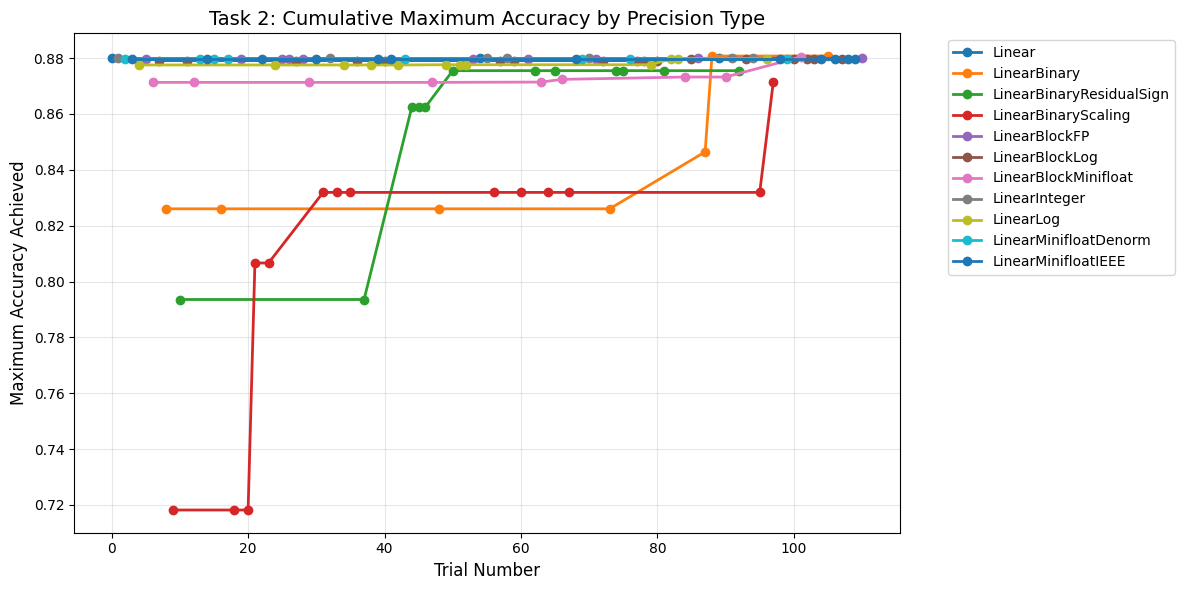


Task 2 — Summary by Precision Type:
                          count    mean     max     std
precision_type                                         
LinearBinary                  7  0.7180  0.8808  0.1671
LinearBlockMinifloat          9  0.7948  0.8804  0.1298
LinearBlockFP                10  0.7537  0.8800  0.1650
LinearInteger                 7  0.8639  0.8800  0.0333
Linear                        3  0.7499  0.8799  0.2165
LinearLog                    12  0.7710  0.8798  0.1447
LinearBlockLog               17  0.8135  0.8798  0.0913
LinearMinifloatDenorm         8  0.8186  0.8797  0.1330
LinearMinifloatIEEE          12  0.7955  0.8796  0.1016
LinearBinaryResidualSign     12  0.7451  0.8755  0.1252
LinearBinaryScaling          14  0.6602  0.8716  0.1423


In [9]:
# Task 2: Cumulative max accuracy per precision type
import matplotlib.pyplot as plt
import numpy as np

# Only use completed trials
df_t2 = df[df['state'] == 'COMPLETE'].copy()
precision_types = df_t2['precision_type'].unique()

plt.figure(figsize=(12, 6))

for ptype in sorted(precision_types):
    if ptype is None:
        continue
    type_df = df_t2[df_t2['precision_type'] == ptype].sort_values('trial_number')
    cumulative_max = type_df['accuracy'].cummax()
    plt.plot(type_df['trial_number'], cumulative_max, marker='o', label=ptype, linewidth=2)

plt.xlabel('Trial Number', fontsize=12)
plt.ylabel('Maximum Accuracy Achieved', fontsize=12)
plt.title('Task 2: Cumulative Maximum Accuracy by Precision Type', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print("\nTask 2 — Summary by Precision Type:")
summary = df_t2.groupby('precision_type')['accuracy'].agg(['count', 'mean', 'max', 'std']).round(4)
print(summary.sort_values('max', ascending=False))

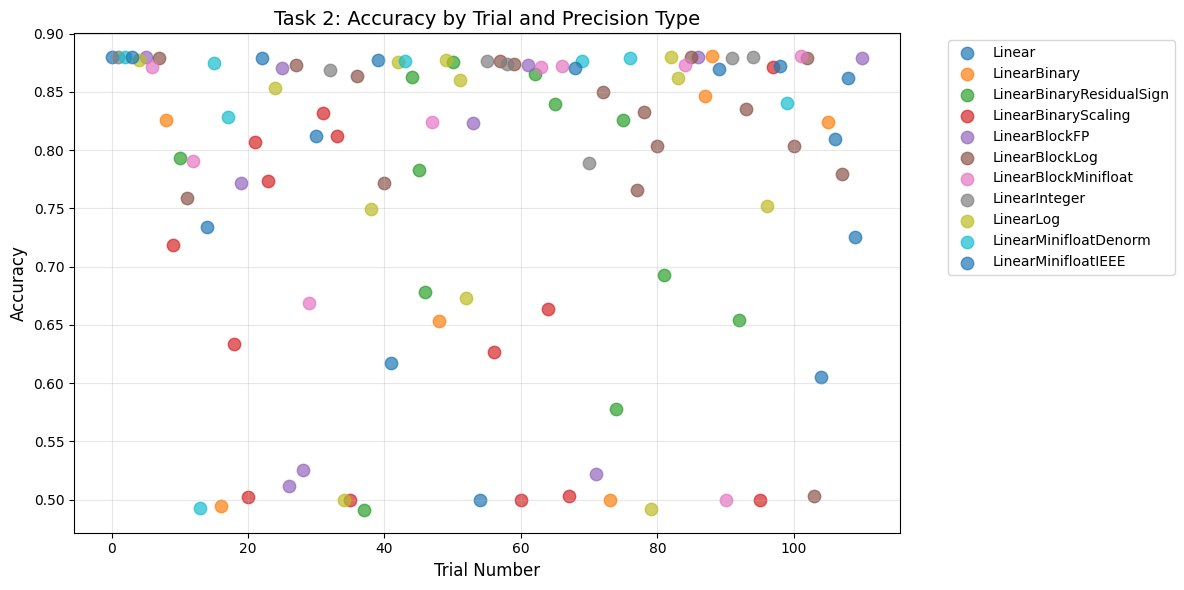


Task 2 Best Trial #88: accuracy = 0.8808
Layer types used: {'LinearBinary': 2, 'LinearMinifloatDenorm': 1, 'LinearBlockMinifloat': 2, 'LinearMinifloatIEEE': 1, 'Linear': 1, 'LinearBlockLog': 1}


In [10]:
# Task 2: Scatter plot of all trials by precision type
plt.figure(figsize=(12, 6))

for ptype in sorted(precision_types):
    if ptype is None:
        continue
    type_df = df_t2[df_t2['precision_type'] == ptype]
    plt.scatter(type_df['trial_number'], type_df['accuracy'], label=ptype, s=80, alpha=0.7)

plt.xlabel('Trial Number', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Task 2: Accuracy by Trial and Precision Type', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print best trial
best_t2 = study.best_trial
print(f"\nTask 2 Best Trial #{best_t2.number}: accuracy = {best_t2.value:.4f}")
type_counts_best = Counter()
for key, val in best_t2.params.items():
    if key.endswith("_type"):
        type_counts_best[val.__name__] += 1
print(f"Layer types used: {dict(type_counts_best)}")